# Análise Exploratória de Dados — PRF 2023

**Disciplina:** Inteligência Artificial  
**Bloco:** B — Classificação/Predição  
**Sistema-alvo:** PRF — Acidentes em Rodovias Federais  

**Fonte dos dados:**  
- URL: https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf  
- Arquivo: `acidentes2023_todas_causas_tipos.csv`  
- Data de acesso: 2026-06-02  
- Licença: Dados Abertos do Governo Federal (dados.gov.br)

**Objetivo:** classificar a gravidade de um acidente em rodovia federal como:
- `Sem Vítimas`
- `Com Vítimas Feridas`
- `Com Vítimas Fatais`

## 1. Importações e Configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid', palette='Set2')

# Caminho do CSV
PROJETO_ROOT = Path().resolve().parent
CSV_PATH = PROJETO_ROOT / 'data' / 'raw' / 'acidentes2023.csv'
print(f'CSV: {CSV_PATH}')
print(f'Existe: {CSV_PATH.exists()}')

CSV: C:\Users\EM09\projeto-ml\data\raw\acidentes2023.csv
Existe: True


## 2. Carregamento dos Dados

In [2]:
# Teste de encoding: tentar latin-1 primeiro, depois utf-8
def carregar_csv_prf(path):
    for enc in ['latin-1', 'utf-8', 'utf-8-sig']:
        try:
            df = pd.read_csv(path, sep=';', encoding=enc, low_memory=False, nrows=100)
            print(f'Encoding bem-sucedido: {enc}')
            # Carregar tudo com encoding confirmado
            df = pd.read_csv(path, sep=';', encoding=enc, low_memory=False)
            return df, enc
        except (UnicodeDecodeError, Exception) as e:
            print(f'Encoding {enc} falhou: {e}')
    raise RuntimeError('Nenhum encoding funcionou.')

df, encoding_usado = carregar_csv_prf(CSV_PATH)
print(f'\nEncoding utilizado: {encoding_usado}')
print(f'Shape do dataset: {df.shape}')

Encoding bem-sucedido: latin-1

Encoding utilizado: latin-1
Shape do dataset: (571052, 37)


## 3. Estrutura do Dataset

In [3]:
print('=== shape() ===')
print(f'{df.shape[0]:,} linhas × {df.shape[1]} colunas')

print('\n=== info() ===')
df.info()

=== shape() ===
571,052 linhas × 37 colunas

=== info() ===
<class 'pandas.DataFrame'>
RangeIndex: 571052 entries, 0 to 571051
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      571052 non-null  int64  
 1   pesid                   515165 non-null  float64
 2   data_inversa            571052 non-null  str    
 3   dia_semana              571052 non-null  str    
 4   horario                 571052 non-null  str    
 5   uf                      571052 non-null  str    
 6   br                      569216 non-null  float64
 7   km                      569216 non-null  str    
 8   municipio               571052 non-null  str    
 9   causa_principal         571052 non-null  str    
 10  causa_acidente          571052 non-null  str    
 11  ordem_tipo_acidente     571052 non-null  int64  
 12  tipo_acidente           571052 non-null  str    
 13  classificacao_acidente  5

In [4]:
print('=== describe() — colunas numéricas ===')
df.describe(include='number').round(2)

=== describe() — colunas numéricas ===


,id,pesid,br,ordem_tipo_acidente,id_veiculo,ano_fabricacao_veiculo,idade,ilesos,feridos_leves,feridos_graves,mortos
count,571052.00,515165.00,569216.00,571052.00,550280.00,550280.00,465604.00,515165.00,515165.00,515165.00,515165.00
mean,535505.33,1179314.67,214.39,1.74,948138.29,1909.26,39.74,0.42,0.34,0.13,0.05
std,22573.77,55723.55,126.96,0.99,43751.55,444.04,39.07,0.49,0.47,0.33,0.22
min,496506.00,1082138.00,10.00,1.00,872933.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,516407.00,1132050.00,116.00,1.00,910948.00,2007.00,27.00,0.00,0.00,0.00,0.00
50%,535517.00,1179269.00,163.00,1.00,947967.00,2013.00,38.00,0.00,0.00,0.00,0.00
75%,554312.00,1225926.00,324.00,2.00,984881.25,2019.00,49.00,1.00,1.00,0.00,0.00
max,620943.00,1389925.00,498.00,12.00,1112778.00,2023.00,2022.00,1.00,1.00,1.00,1.00


In [5]:
print('=== describe() — colunas categóricas ===')
df.describe(include='object').T

=== describe() — colunas categóricas ===


,count,unique,top,freq
data_inversa,571052,365,2023-06-11,3370
dia_semana,571052,7,domingo,99992
horario,571052,1406,17:00:00,8125
uf,571052,27,MG,79876
km,569216,7637,2,2290
municipio,571052,1826,BRASILIA,8196
causa_principal,571052,2,Sim,319189
causa_acidente,571052,76,Reação tardia ou ineficiente do condutor,80189
tipo_acidente,571052,16,Colisão traseira,82758
classificacao_acidente,571049,3,Com Vítimas Feridas,421356


## 4. Valores Nulos por Coluna

Colunas com valores nulos: 18
                         nulos  pct_%
idade                   105448  18.47
pesid                    55887   9.79
feridos_graves           55887   9.79
tipo_envolvido           55887   9.79
estado_fisico            55887   9.79
mortos                   55887   9.79
ilesos                   55887   9.79
feridos_leves            55887   9.79
sexo                     55887   9.79
tipo_veiculo             20772   3.64
ano_fabricacao_veiculo   20772   3.64
id_veiculo               20772   3.64
br                        1836   0.32
km                        1836   0.32
uop                        656   0.11
delegacia                  557   0.10
regional                   150   0.03
classificacao_acidente       3   0.00


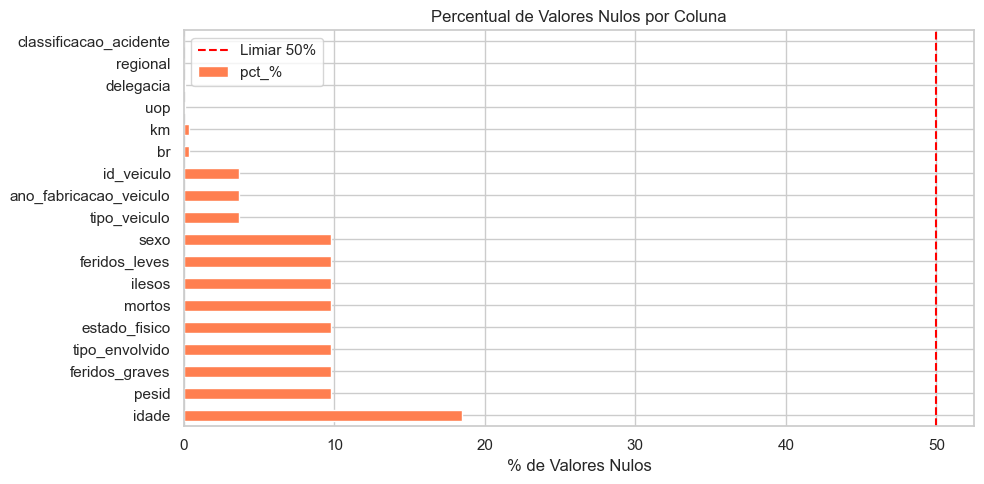

In [6]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'nulos': nulos, 'pct_%': pct_nulos})
resumo_nulos = resumo_nulos[resumo_nulos['nulos'] > 0].sort_values('pct_%', ascending=False)

print(f'Colunas com valores nulos: {len(resumo_nulos)}')
print(resumo_nulos.to_string())

# Gráfico de barras dos nulos
fig, ax = plt.subplots(figsize=(10, 5))
resumo_nulos['pct_%'].plot(kind='barh', ax=ax, color='coral')
ax.axvline(50, color='red', linestyle='--', label='Limiar 50%')
ax.set_xlabel('% de Valores Nulos')
ax.set_title('Percentual de Valores Nulos por Coluna')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Distribuição da Variável-Alvo (`classificacao_acidente`)

Distribuição da variável-alvo:
classificacao_acidente
Com Vítimas Feridas    421356
Com Vítimas Fatais      93332
Sem Vítimas             56361
Name: count, dtype: int64

Proporção (%):
classificacao_acidente
Com Vítimas Feridas    73.79
Com Vítimas Fatais     16.34
Sem Vítimas             9.87
Name: count, dtype: float64


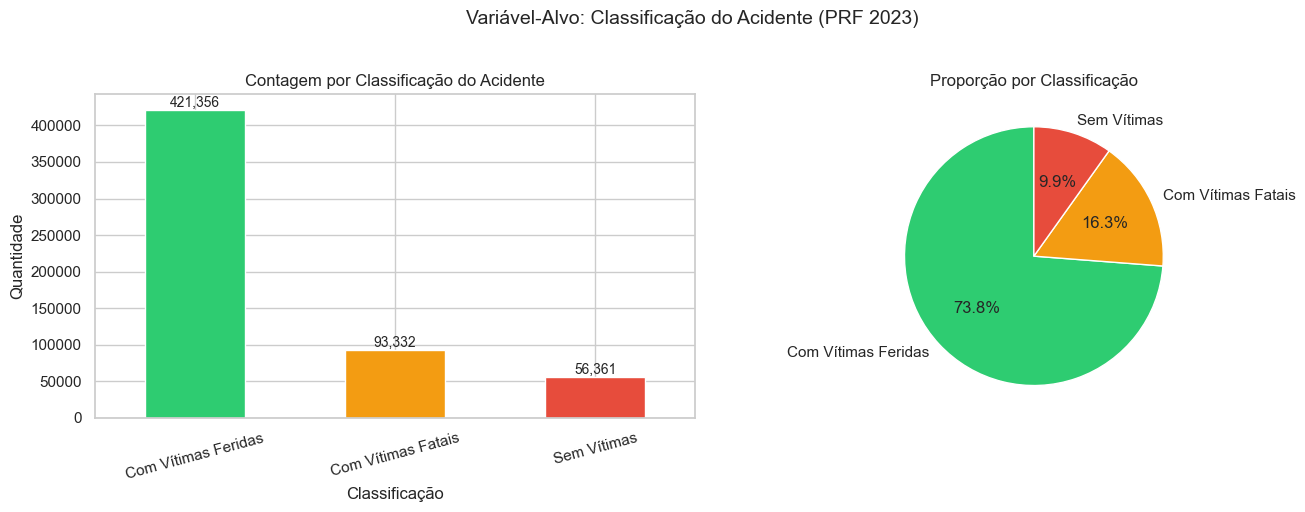

In [7]:
contagem_target = df['classificacao_acidente'].value_counts()
print('Distribuição da variável-alvo:')
print(contagem_target)
print(f'\nProporção (%):')
print((contagem_target / len(df) * 100).round(2))

# Gráficos: barras + pizza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#2ECC71', '#F39C12', '#E74C3C']

contagem_target.plot(kind='bar', ax=axes[0], color=cores, edgecolor='white')
axes[0].set_title('Contagem por Classificação do Acidente')
axes[0].set_xlabel('Classificação')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

axes[1].pie(contagem_target, labels=contagem_target.index, autopct='%1.1f%%',
            colors=cores, startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporção por Classificação')

plt.suptitle('Variável-Alvo: Classificação do Acidente (PRF 2023)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Top 10 Causas de Acidente

Top 10 causas de acidente:
causa_acidente
Reação tardia ou ineficiente do condutor                     80189
Ausência de reação do condutor                               63961
Velocidade Incompatível                                      54210
Condutor deixou de manter distância do veículo da frente     39452
Acessar a via sem observar a presença dos outros veículos    36524
Manobra de mudança de faixa                                  31095
Ingestão de álcool pelo condutor                             27073
Transitar na contramão                                       21846
Condutor Dormindo                                            17845
Ultrapassagem Indevida                                       17738


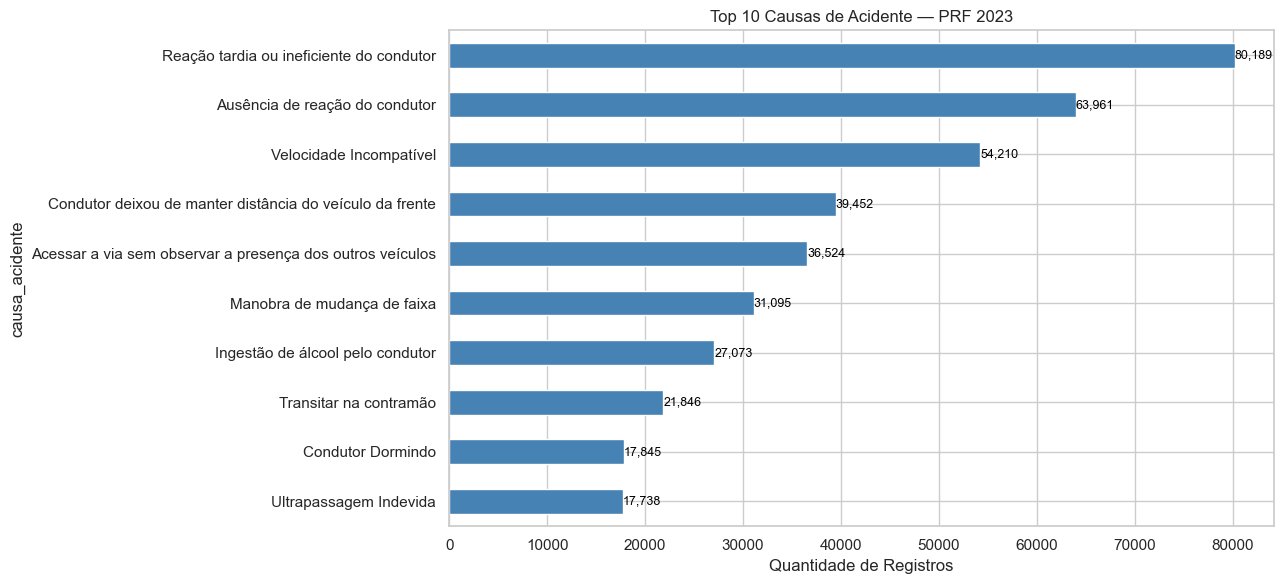

In [8]:
top_causas = df['causa_acidente'].value_counts().head(10)
print('Top 10 causas de acidente:')
print(top_causas.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
top_causas.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Causas de Acidente — PRF 2023')
ax.set_xlabel('Quantidade de Registros')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9, color='black')
plt.tight_layout()
plt.show()

## 7. Distribuição por UF

Acidentes por UF:
uf
MG    79876
PR    70464
SC    51019
RS    41060
SP    38158
BA    32284
RJ    28240
GO    27812
MT    24493
MS    24002
PE    22758
RO    19206
PA    14731
PI    14025
ES    12385
PB    12308
MA    11628
CE    10848
DF     8196
RN     7922
TO     7639
AL     3058
SE     3021
AC     1924
AM     1676
RR     1315
AP     1004


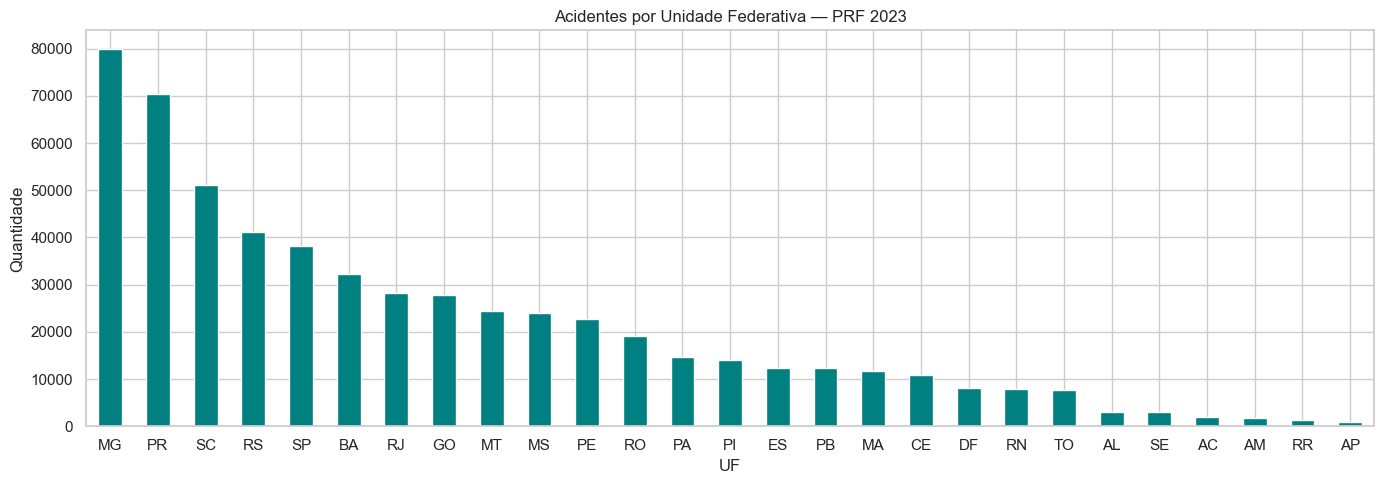

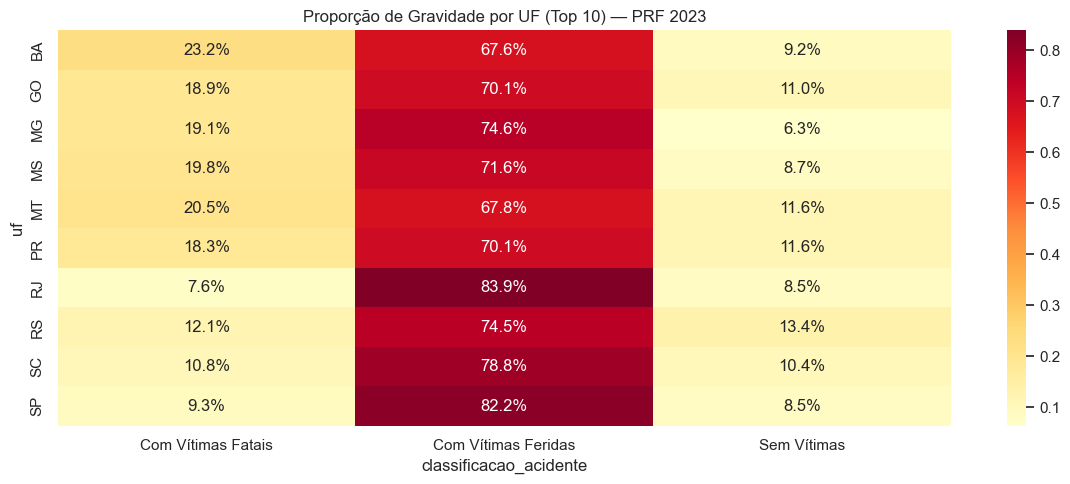

In [9]:
por_uf = df['uf'].value_counts().sort_values(ascending=False)
print('Acidentes por UF:')
print(por_uf.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
por_uf.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Acidentes por Unidade Federativa — PRF 2023')
ax.set_xlabel('UF')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Heatmap de gravidade × UF (top 10 UFs)
top10_ufs = por_uf.head(10).index.tolist()
heatmap_data = (
    df[df['uf'].isin(top10_ufs)]
    .groupby(['uf', 'classificacao_acidente'])
    .size()
    .unstack(fill_value=0)
)
heatmap_data_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0).round(3)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heatmap_data_pct, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax)
ax.set_title('Proporção de Gravidade por UF (Top 10) — PRF 2023')
plt.tight_layout()
plt.show()

## 8. Acidentes por Hora do Dia

Acidentes por hora do dia:
hora
0     12075
1      9944
2      7915
3     11140
4     13108
5     18907
6     25014
7     35334
8     29134
9     22958
10    25149
11    23344
12    23663
13    25484
14    28724
15    30010
16    32230
17    38650
18    43188
19    34975
20    25739
21    21052
22    18302
23    15013


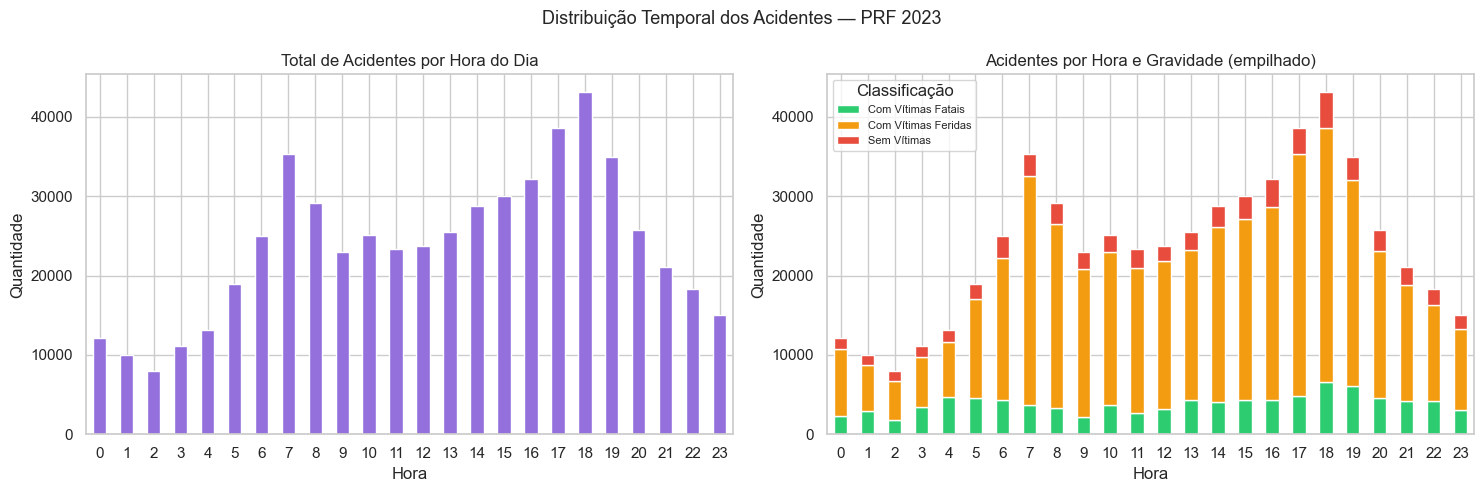

In [10]:
# Extrair a hora do campo horario (formato HH:MM:SS)
df['hora'] = pd.to_datetime(df['horario'], format='%H:%M:%S', errors='coerce').dt.hour

por_hora = df.groupby('hora').size()
print('Acidentes por hora do dia:')
print(por_hora.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total por hora
por_hora.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Total de Acidentes por Hora do Dia')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=0)

# Gravidade por hora
hora_gravidade = (
    df.groupby(['hora', 'classificacao_acidente'])
    .size()
    .unstack(fill_value=0)
)
cores_grav = ['#2ECC71', '#F39C12', '#E74C3C']
hora_gravidade.plot(kind='bar', ax=axes[1], color=cores_grav, stacked=True, edgecolor='white')
axes[1].set_title('Acidentes por Hora e Gravidade (empilhado)')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Classificação', loc='upper left', fontsize=8)

plt.suptitle('Distribuição Temporal dos Acidentes — PRF 2023', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Análises Adicionais

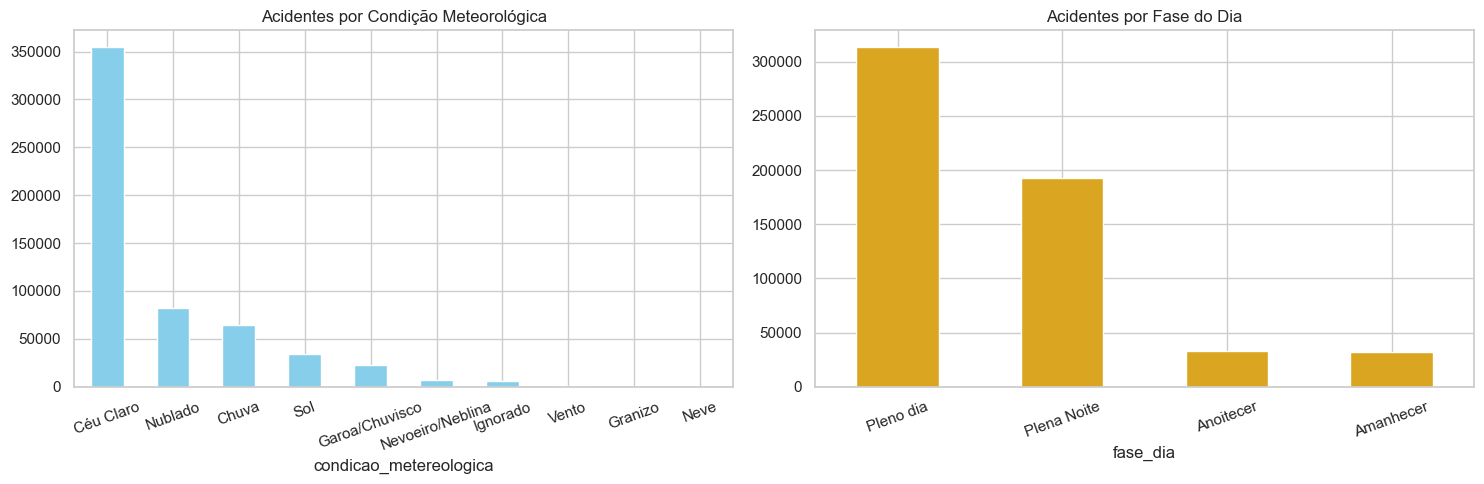

In [11]:
# Condição meteorológica
condicao = df['condicao_metereologica'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

condicao.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='white')
axes[0].set_title('Acidentes por Condição Meteorológica')
axes[0].tick_params(axis='x', rotation=20)

# Fase do dia
fase = df['fase_dia'].value_counts()
fase.plot(kind='bar', ax=axes[1], color='goldenrod', edgecolor='white')
axes[1].set_title('Acidentes por Fase do Dia')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

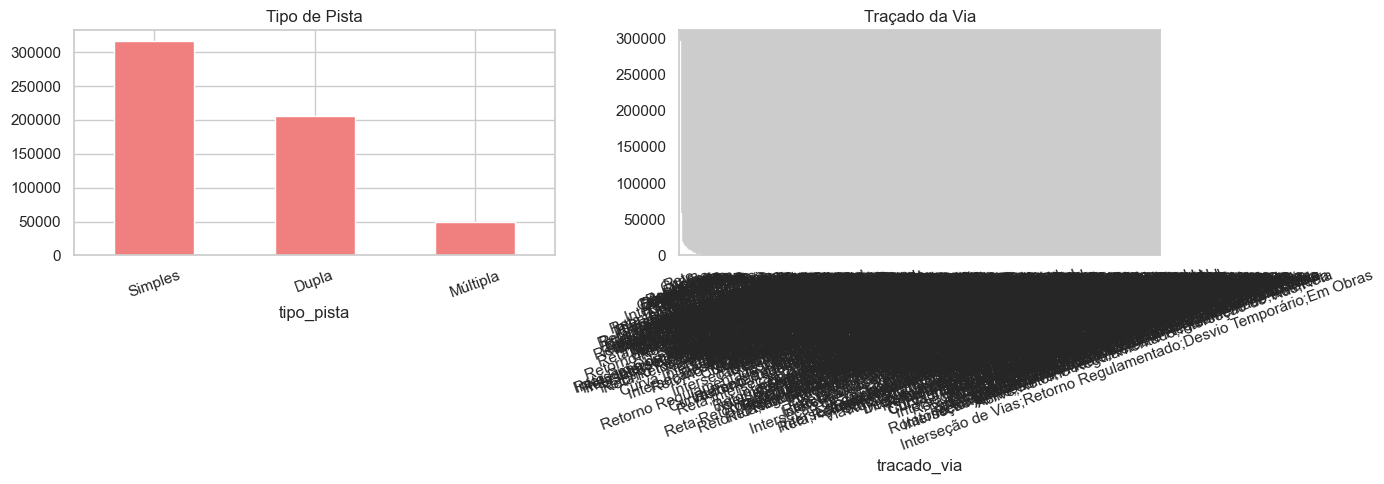

In [12]:
# Tipo de pista e traçado da via
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['tipo_pista'].value_counts().plot(kind='bar', ax=axes[0], color='lightcoral', edgecolor='white')
axes[0].set_title('Tipo de Pista')
axes[0].tick_params(axis='x', rotation=20)

df['tracado_via'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='white')
axes[1].set_title('Traçado da Via')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. Considerações Éticas e LGPD

### 10.1 Lei Geral de Proteção de Dados (LGPD)

O dataset da PRF **não contém dados pessoais identificáveis**. Não há colunas com:
- CPF, RG ou número de documento
- Nome de pessoas envolvidas
- Endereço residencial
- Dados de contato (e-mail, telefone)

As colunas `idade` e `sexo`, quando presentes, representam **atributos agregados** do acidente (não identificam um indivíduo específico) e são usadas apenas em análise estatística, nunca para rastrear pessoas.

Portanto, o uso deste dataset para fins educacionais e de pesquisa está em conformidade com a LGPD (Lei nº 13.709/2018).

### 10.2 Viés Regional

**Atenção:** O dataset apresenta viés regional. Alguns estados (SP, MG, PR, RS) concentram **mais de 50% dos registros** não necessariamente porque têm mais acidentes per capita, mas porque têm:
- Maior extensão de rodovias federais
- Melhor cobertura de registros (mais delegacias PRF)
- Maior volume de tráfego

Um modelo treinado nesses dados pode ter desempenho inferior para estados do Norte e Centro-Oeste, onde há subnotificação. Recomenda-se usar `class_weight='balanced'` e avaliar métricas por UF separadamente antes de implantar o sistema.

### 10.3 Viés Temporal

O modelo é treinado com dados de 2023. Mudanças nas rodovias (obras, novos trechos), comportamento dos motoristas, ou alterações na legislação de trânsito podem tornar o modelo desatualizado. Retreino anual é recomendado.

### 10.4 Uso Ético da Predição

O sistema de classificação **auxilia a triagem**, não substitui a decisão humana de agentes da PRF. Predições com alta probabilidade de 'Com Vítimas Fatais' devem acionar protocolo de emergência, mas um agente deve sempre confirmar presencialmente.

In [13]:
# Resumo estatístico do dataset para o relatório
print('=== RESUMO PARA RELATÓRIO ===')
print(f'Total de registros: {len(df):,}')
print(f'Total de colunas: {df.shape[1]}')
print(f'Período: {df["data_inversa"].min()} a {df["data_inversa"].max()}')
print(f'UFs cobertas: {df["uf"].nunique()}')
print(f'\nDistribuição da target:')
for cat, cnt in df['classificacao_acidente'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f'  {cat}: {cnt:,} ({pct:.1f}%)')

=== RESUMO PARA RELATÓRIO ===
Total de registros: 571,052
Total de colunas: 38
Período: 2023-01-01 a 2023-12-31
UFs cobertas: 27

Distribuição da target:
  Com Vítimas Feridas: 421,356 (73.8%)
  Com Vítimas Fatais: 93,332 (16.3%)
  Sem Vítimas: 56,361 (9.9%)
